In [12]:
from pathlib import Path
import pandas as pd

dfs = []

for path in Path("data").glob("*.parquet"):
    dfs.append(pd.read_parquet(path))

df = pd.concat(dfs, ignore_index=True)

print(df.shape)

df.head(1)

(205, 46)


,session_id,record_id,tool,tool_version,category,command,params,shell_block,inputs,outputs,...,l2_cache_kb,l3_cache_kb,cpu_freq_mhz,os,kernel_version,kernel_string,sm_version,deploy_mode,workflow_url,workflow_version
0,c212bb7f-0f24-420a-bd89-1c7636fe1bd9,0078fed0c938b4df,gzip,,,gzip,-c {input} > {output},,,,...,0,0,0,linux,6.18.7-76061807-generic,Linux-6.18.7-76061807-generic-x86_64-with-glib...,9.16.4.dev25,host,,


In [13]:
numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

corr = df[numeric_cols].corr()

corr["runtime_sec"].sort_values(
    ascending=False
)

runtime_sec     1.000000
cpu_percent     0.866311
cpu_time_sec    0.542336
max_rss_mb      0.400374
num_inputs      0.364871
input_size      0.340523
max_vms_mb      0.301447
threads         0.279123
max_uss_mb      0.253078
max_pss_mb      0.251509
output_size     0.058965
cpu_freq_mhz    0.057721
cpu_cores       0.057721
l3_cache_kb     0.057721
l2_cache_kb     0.057721
swap_used_mb    0.051546
mem_avail_mb    0.041947
io_out_mb       0.040269
io_wait_pct     0.022607
num_outputs    -0.038841
io_in_mb       -0.039367
load_avg       -0.131121
exit_code            NaN
Name: runtime_sec, dtype: float64

In [4]:
corr["max_rss_mb"].sort_values(
    ascending=False
)

max_rss_mb      1.000000
threads         0.676130
cpu_percent     0.663410
max_uss_mb      0.605553
max_pss_mb      0.604695
max_vms_mb      0.596396
cpu_time_sec    0.406739
runtime_sec     0.400374
num_inputs      0.366839
load_avg        0.212172
cpu_freq_mhz    0.088056
l3_cache_kb     0.088056
cpu_cores       0.088056
l2_cache_kb     0.088056
swap_used_mb    0.079655
input_size      0.070933
output_size     0.051976
mem_avail_mb    0.046642
io_wait_pct     0.041614
io_out_mb       0.018282
num_outputs    -0.037389
io_in_mb       -0.040077
exit_code            NaN
Name: max_rss_mb, dtype: float64

In [5]:
features_m1 = [
    "tool",
    "command",
    "input_size",
    "threads",
]

features_m2 = [
    "tool",
    "command",
    "input_size",
    "output_size",
    "num_inputs",
    "num_outputs",
    "threads",
]

features_m3 = [
    "tool",
    "command",
    "input_size",
    "output_size",
    "num_inputs",
    "num_outputs",
    "threads",
    "cpu_cores",
    "cpu_freq_mhz",
    "mem_avail_mb",
]

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def evaluate(features, target):

    X = df[features]
    y = df[target]

    categorical = [
        c for c in features
        if df[c].dtype.name in [
            "str",
            "string",
            "object",
        ]
    ]

    numeric = [
        c for c in features
        if c not in categorical
    ]

    preprocess = ColumnTransformer(
        [
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical,
            ),
            (
                "num",
                "passthrough",
                numeric,
            ),
        ]
    )

    model = Pipeline(
        [
            ("prep", preprocess),
            (
                "rf",
                RandomForestRegressor(
                    n_estimators=100,
                    random_state=42,
                ),
            ),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return {
        "MAE": mean_absolute_error(
            y_test,
            pred,
        ),
        "R2": r2_score(
            y_test,
            pred,
        ),
        "pred": pred,
        "y_test": y_test,
    }

In [7]:
for name, features in {
    "M1": features_m1,
    "M2": features_m2,
    "M3": features_m3,
}.items():

    result = evaluate(
        features,
        "runtime_sec",
    )

    print(
        name,
        "R2=",
        round(result["R2"], 3),
        "MAE=",
        round(result["MAE"], 3),
    )

M1 R2= 0.798 MAE= 1.56
M2 R2= 0.798 MAE= 1.558
M3 R2= 0.797 MAE= 1.576


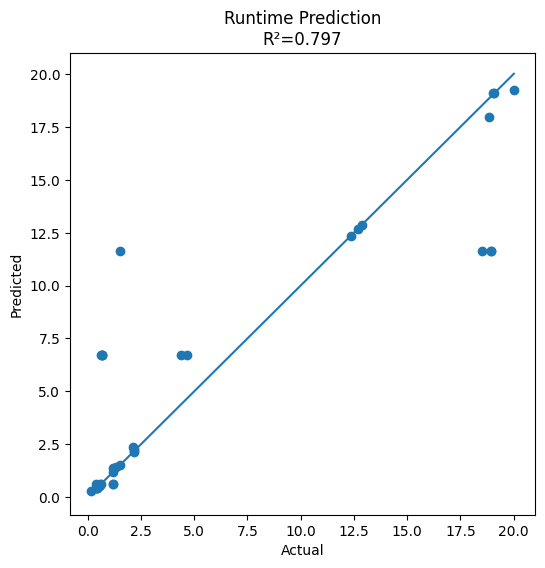

In [8]:
import matplotlib.pyplot as plt

result = evaluate(
    features_m3,
    "runtime_sec",
)

plt.figure(figsize=(6,6))

plt.scatter(
    result["y_test"],
    result["pred"],
)

mn = min(
    result["y_test"].min(),
    result["pred"].min(),
)

mx = max(
    result["y_test"].max(),
    result["pred"].max(),
)

plt.plot(
    [mn, mx],
    [mn, mx],
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    f"Runtime Prediction\nR²={result['R2']:.3f}"
)

plt.show()